# CNN

In [1]:
import tensorflow as tf

strategy = tf.distribute.MirroredStrategy()

print("Numero di GPU:", strategy.num_replicas_in_sync)

2026-08-30 10:00:55.706699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788084055.925003      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788084055.987305      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788084056.519434      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788084056.519479      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788084056.519483      59 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Numero di GPU: 2


I0000 00:00:1788084071.372508      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788084071.378309      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
import os
import json
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)



DATASET_PATH = "/kaggle/input/datasets/pierlucadipalma/segmentedplant2/segmentedSplit/"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH   = os.path.join(DATASET_PATH, "val")
TEST_PATH  = os.path.join(DATASET_PATH, "test")


IMG_SIZE = (240,240)

BATCH_SIZE = 64

EPOCHS = 15

NUM_CLASSES = 38


MODEL_PATH = "/kaggle/working/best_model.keras"

CLASS_PATH = "/kaggle/working/class_names.json"


print("GPU disponibili:")
print(tf.config.list_physical_devices("GPU"))


tf.keras.mixed_precision.set_global_policy("mixed_float16")


strategy = tf.distribute.MirroredStrategy()


print("Numero GPU utilizzate:", strategy.num_replicas_in_sync)


2026-08-30 13:22:50.458541: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788096170.686177      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788096170.754937      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788096171.291797      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788096171.291827      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788096171.291830      58 computation_placer.cc:177] computation placer alr

GPU disponibili:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Numero GPU utilizzate: 2


I0000 00:00:1788096184.960353      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788096184.966098      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)




class_names = train_ds.class_names


with open(CLASS_PATH,"w") as f:
    json.dump(class_names,f)


print("Classi:")
print(class_names)

Found 43430 files belonging to 38 classes.
Found 5417 files belonging to 38 classes.
Found 5459 files belonging to 38 classes.
Classi:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___

In [4]:
CLASS_PATH = "/kaggle/input/datasets/pierlucadipalma/classnames/class_names.json"
with open(CLASS_PATH, "r") as f:
    class_names = json.load(f)
    print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [5]:


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.3
    ),

    layers.RandomZoom(
        0.15
    ),

    layers.RandomContrast(
        0.2
    )

])

In [6]:


def create_model():


    model = models.Sequential([
        layers.Input(shape=(240,240,3)),
        
        layers.Rescaling(1./255),
        
        augmentation,


        #Block 1

        layers.Conv2D(32, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.Conv2D(32, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.MaxPooling2D(),



        #Block 2

        layers.Conv2D(64, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.Conv2D(64, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.MaxPooling2D(),



        #Block 3

        layers.Conv2D(128, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.Conv2D(128, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),

        layers.MaxPooling2D(),

        #Block 4

        layers.Conv2D(256,3,padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.Conv2D(256, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),


        layers.MaxPooling2D(),



        #Block 5

        layers.Conv2D(512, 3, padding="same"),

        layers.BatchNormalization(),

        layers.Activation("relu"),



        layers.GlobalAveragePooling2D(name="feature_extractor"),



        layers.Dense(256, activation="relu"),

        layers.Dropout(0.5),

        layers.Dense(128, activation="relu"),

        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")

    ])


    return model





In [7]:

with strategy.scope():
    model = create_model()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy", metrics=["accuracy"])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 240, 240, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 240, 240, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 240, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 240, 240, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 120, 120, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 60, 60, 128)    │             

 Total params: 2,527,430 (9.64 MB)

 Trainable params: 2,524,486 (9.63 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [8]:

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)



early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)



reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

In [ ]:


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint,early_stop,reduce_lr]

)

print("Test evaluation:")

test_loss, test_acc = model.evaluate(test_ds)


print("Test accuracy:", test_acc)


model.save("/kaggle/working/final_model.keras")

print("Training completed")

In [9]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

MODEL_PATH = "/kaggle/input/models/pierlucadipalma/plantvillagemodel/tensorflow2/default/1/best_model (1).keras"
model = tf.keras.models.load_model(MODEL_PATH)

y_prob = model.predict(test_ds)

y_pred = np.argmax(y_prob, axis=1)

y_test = np.concatenate([
    np.argmax(y, axis=1) for x, y in test_ds
])

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

I0000 00:00:1788084479.150256     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9375    0.9524    0.9449        63
                                 Apple___Black_rot     1.0000    0.9683    0.9839        63
                          Apple___Cedar_apple_rust     0.9655    1.0000    0.9825        28
                                   Apple___healthy     0.9483    1.0000    0.9735       165
                               Blueberry___healthy     0.9869    1.0000    0.9934       151
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9717    0.9856       106
                 Cherry_(including_sour)___healthy     1.0000    0.9884    0.9942        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8125    0.7500    0.7800        52
                       Corn_(maize)___Common_rust_     0.9440    0.9833    0.9633       120
               Corn_(maize)___Norther

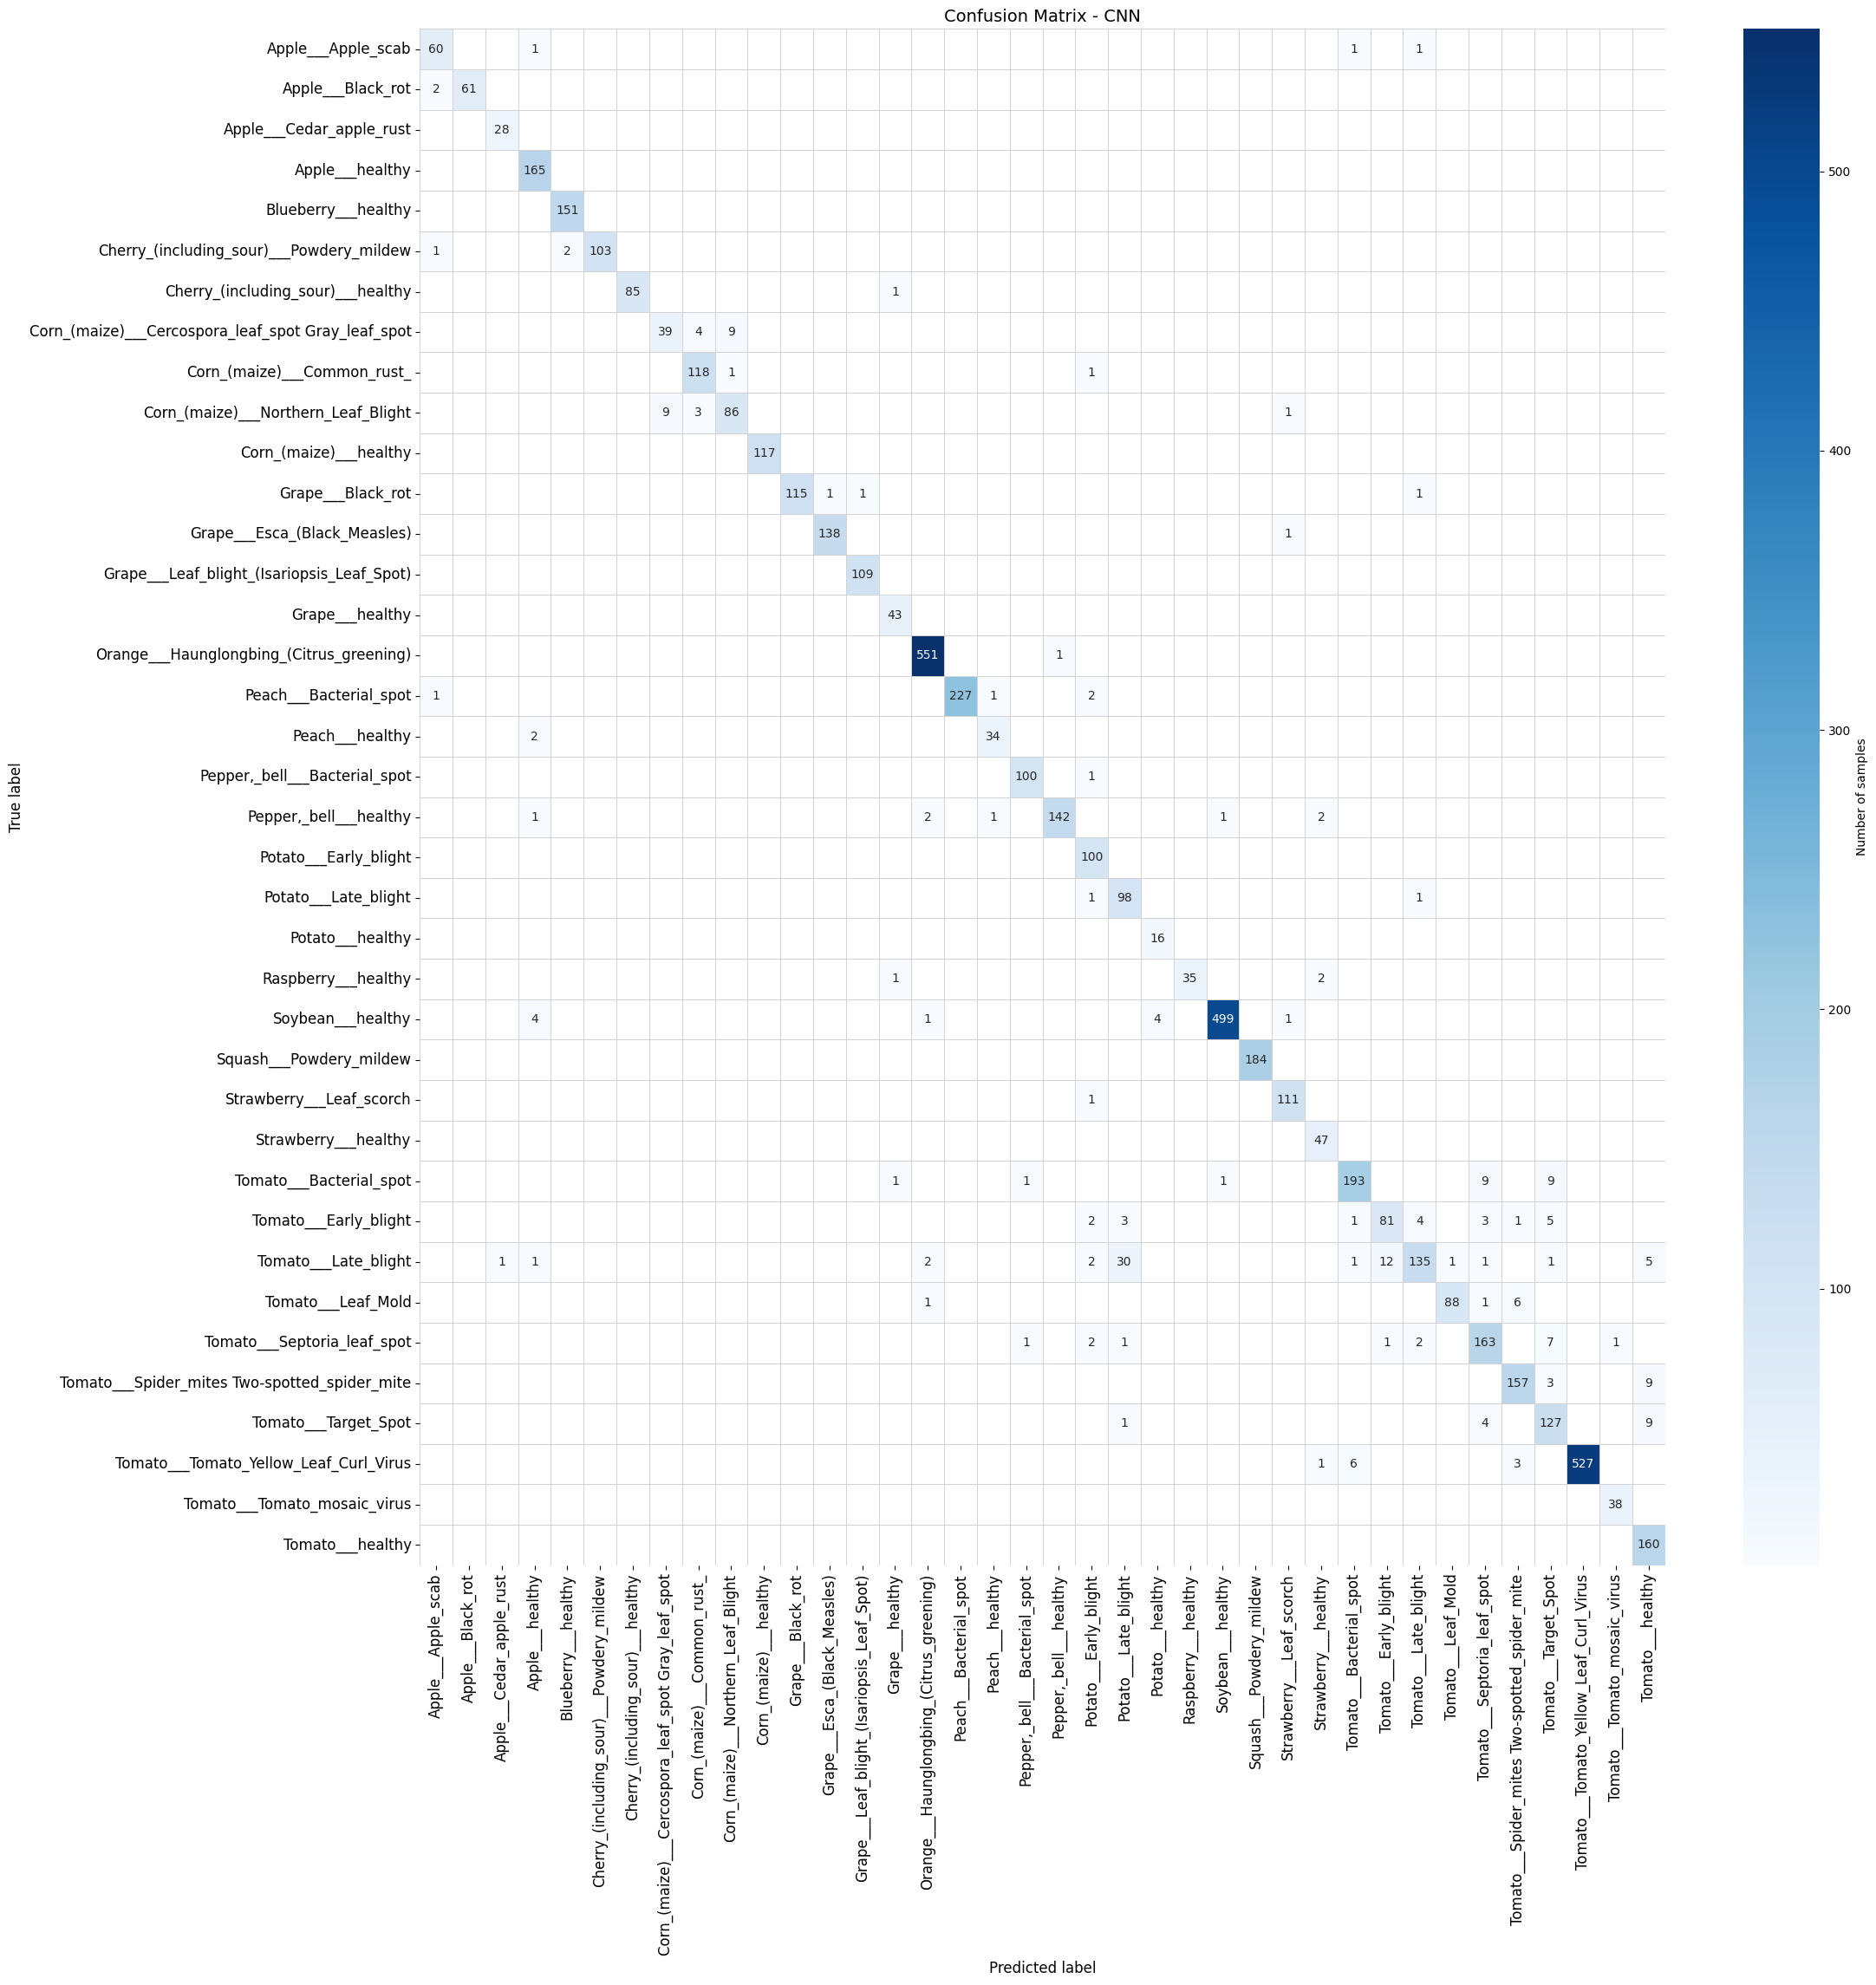

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

mask = cm == 0

annot = np.where(cm == 0, '', cm.astype(str))

n_classes = len(class_names)
fig, ax = plt.subplots(figsize=(n_classes * 0.5 + 4, n_classes * 0.5 + 4))

sns.heatmap(
    cm,
    mask=mask,          
    annot=annot,        
    fmt='',             
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgray',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of samples'},
    ax=ax
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix - CNN', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

plt.savefig('/kaggle/working/confusion_matrix_CNN.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
new_input = layers.Input(shape=(240, 240, 3))
x = new_input

for layer in model.layers:
    x = layer(x)  
    if layer.name == "feature_extractor":
        feature_output = x
        break

feature_extractor = models.Model(inputs=new_input, outputs=feature_output)

In [16]:
def extract_features(dataset, feature_extractor):
    features_list = []
    labels_list = []

    for images, labels in dataset:
        feats = feature_extractor.predict(images, verbose=0)

        features_list.append(feats)

        # Da one-hot → indice della classe
        labels_list.append(np.argmax(labels.numpy(), axis=1))

    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)

    return X, y

In [ ]:
X_train, y_train = extract_features(train_ds, feature_extractor)
X_val,   y_val   = extract_features(val_ds,   feature_extractor)
X_test,  y_test  = extract_features(test_ds,  feature_extractor)

print(X_train.shape, X_val.shape, X_test.shape)  



In [ ]:
np.savez("/kaggle/working/features.npz",
         X_train=X_train, y_train=y_train,
         X_val=X_val,     y_val=y_val,
         X_test=X_test,   y_test=y_test)

Feature loading

In [2]:
import numpy as np
data = np.load("/kaggle/input/datasets/pierlucadipalma/featuresvector/features.npz")

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

# KNN 

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


k_values = [10, 20, 30, 40, 50, 60, 80, 100, 150, 190]

results = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)

    results[k] = score
    print(f"K = {k:3d} -> Accuracy = {score:.4f}")


best_k = max(results, key=results.get)
best_score = results[best_k]

print("\nMiglior risultato:")
print(f"K = {best_k}")
print(f"Accuracy = {best_score:.4f}")



K =  10 -> Accuracy = 0.9834
K =  20 -> Accuracy = 0.9782
K =  30 -> Accuracy = 0.9760
K =  40 -> Accuracy = 0.9745
K =  50 -> Accuracy = 0.9743
K =  60 -> Accuracy = 0.9736
K =  80 -> Accuracy = 0.9701
K = 100 -> Accuracy = 0.9681
K = 150 -> Accuracy = 0.9631
K = 190 -> Accuracy = 0.9601

Miglior risultato:
K = 10
Accuracy = 0.9834


In [13]:
from sklearn.neighbors import KNeighborsClassifier
import pickle
best_model = KNeighborsClassifier(n_neighbors=10)
best_model.fit(X_train, y_train)

with open('/kaggle/working/modelKnn.p', 'wb') as f:
    pickle.dump(best_model, f)

In [14]:
from sklearn.metrics import classification_report, accuracy_score


with open('/kaggle/working/modelKnn.p', 'rb') as f:
    best_model = pickle.load(f)

y_pred = best_model.predict(X_test)


print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


Classification Report

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9683    0.9839        63
                                 Apple___Black_rot     1.0000    1.0000    1.0000        63
                          Apple___Cedar_apple_rust     0.9655    1.0000    0.9825        28
                                   Apple___healthy     0.9880    1.0000    0.9940       165
                               Blueberry___healthy     0.9869    1.0000    0.9934       151
          Cherry_(including_sour)___Powdery_mildew     0.9907    1.0000    0.9953       106
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8600    0.8269    0.8431        52
                       Corn_(maize)___Common_rust_     0.9917    1.0000    0.9959       120
               Corn_(maize)___Northern_Leaf_Blight     

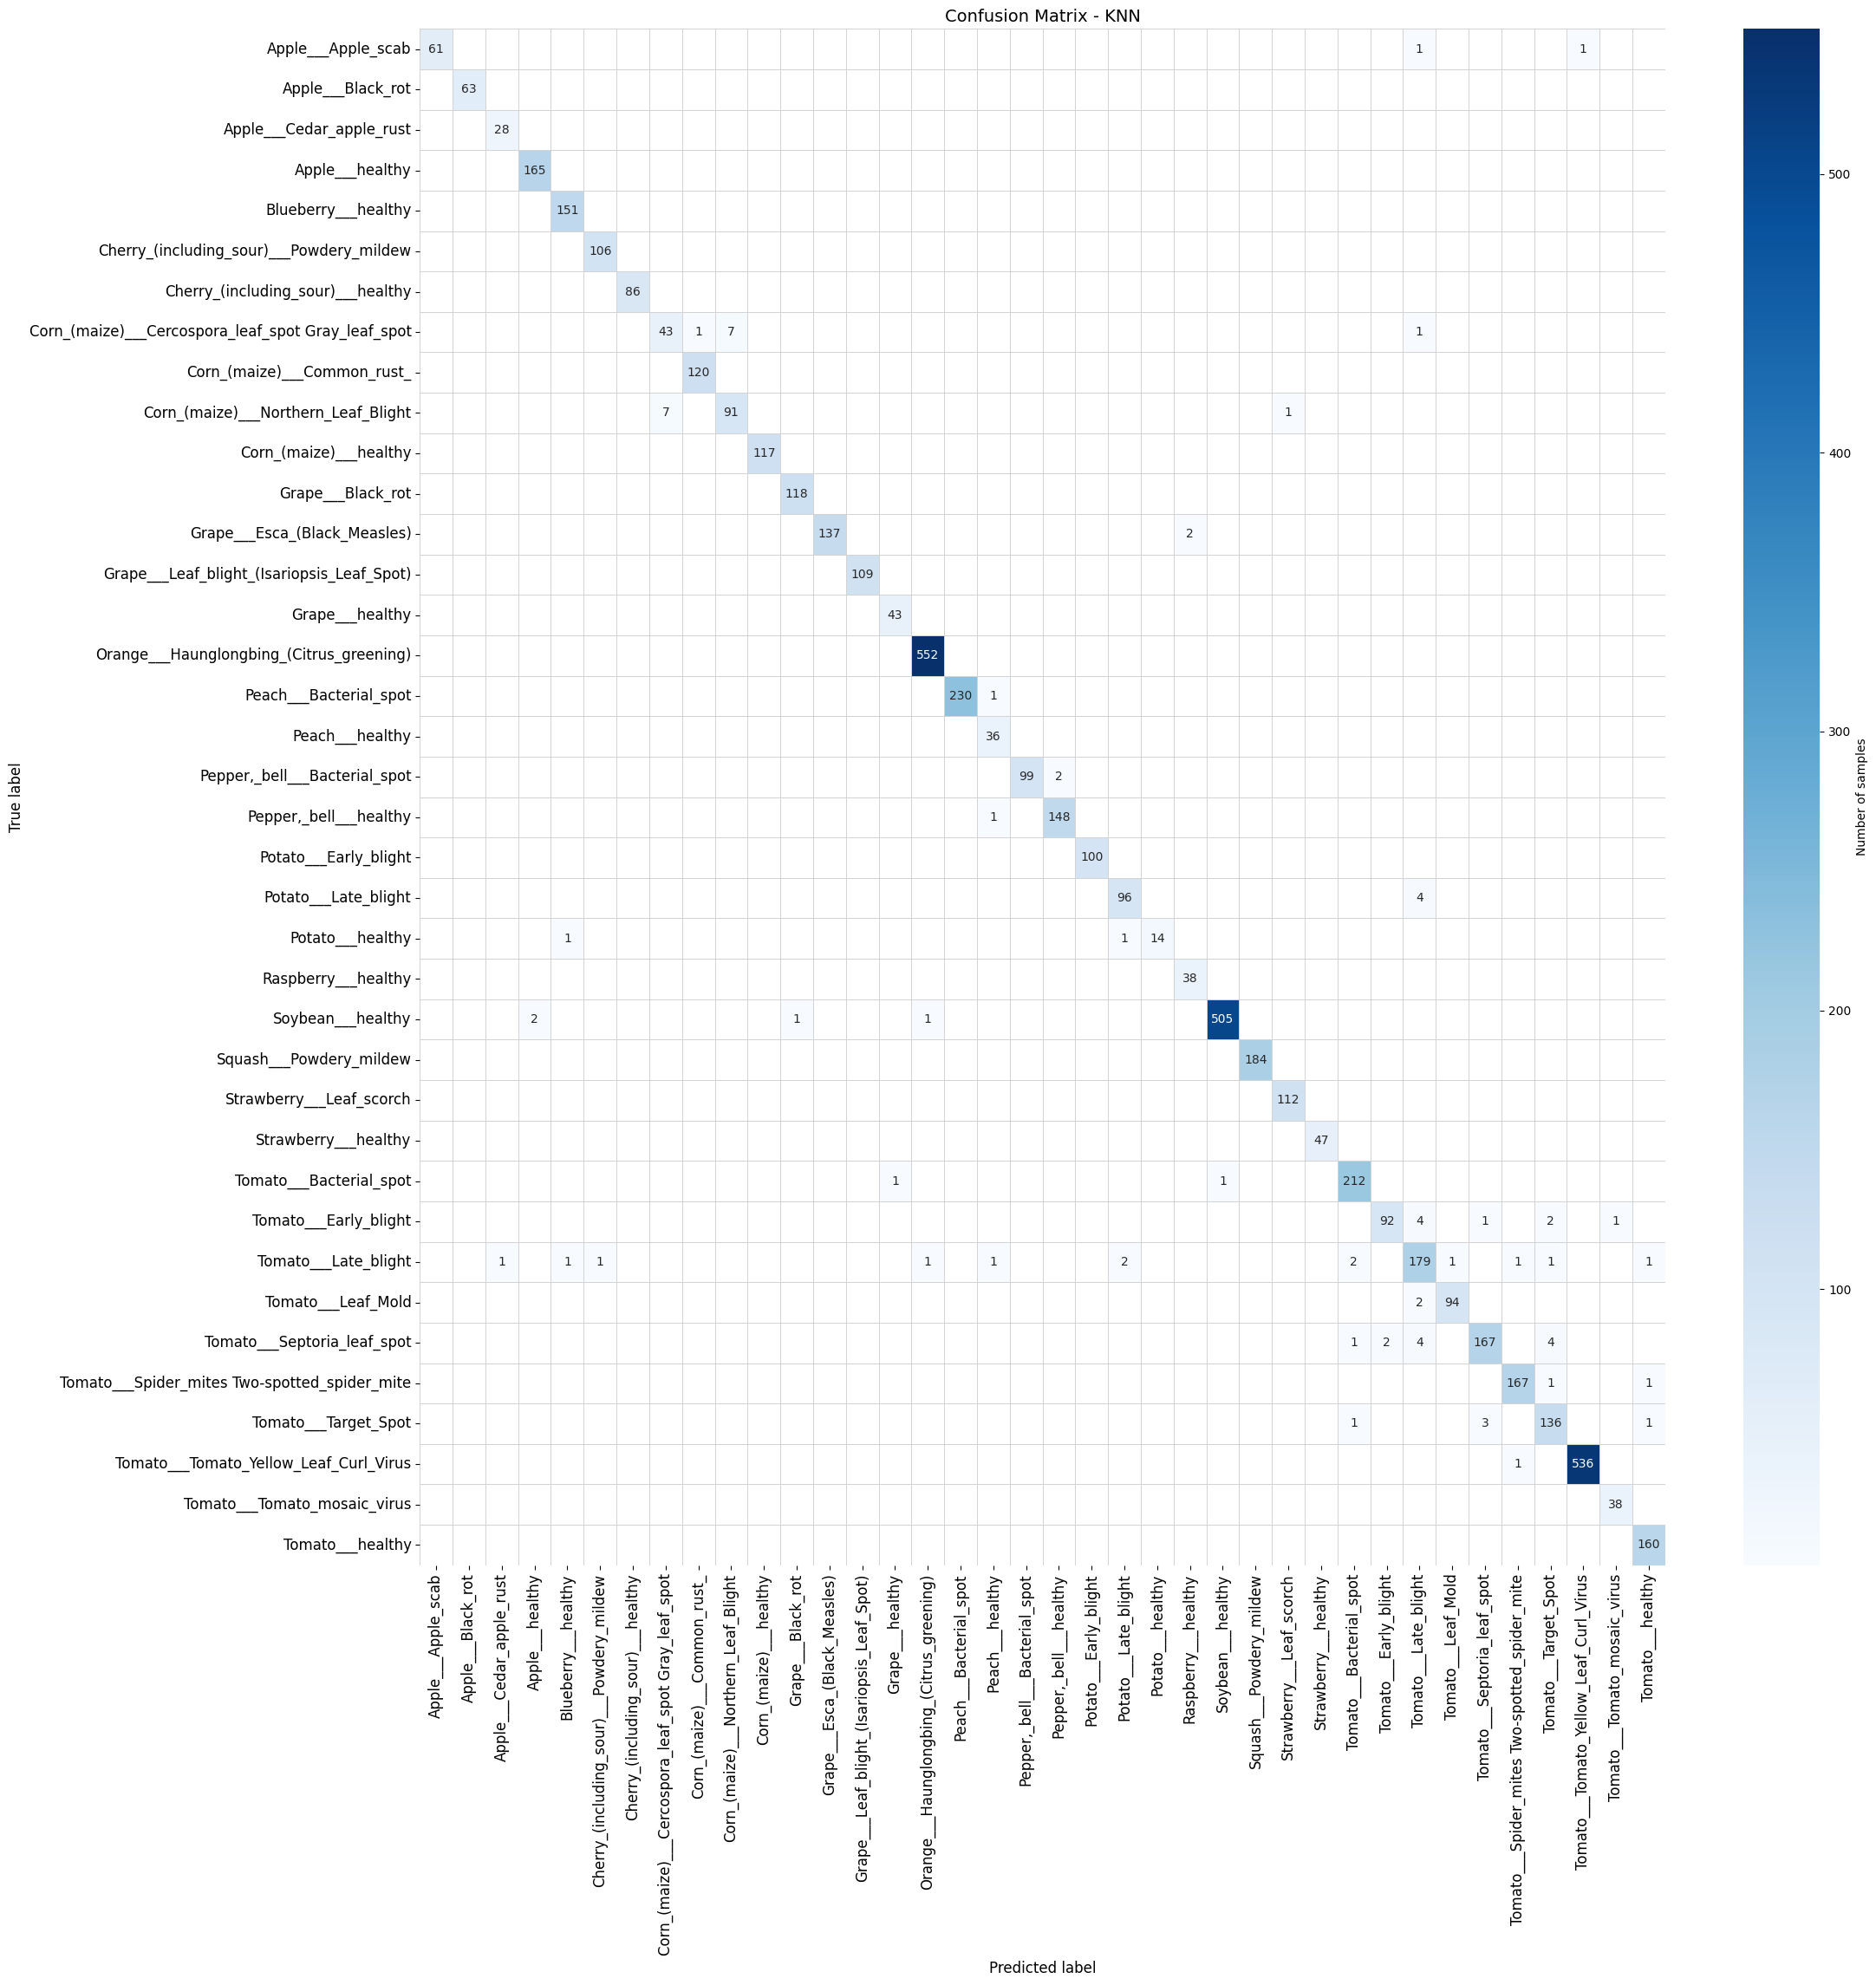

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

mask = cm == 0

annot = np.where(cm == 0, '', cm.astype(str))

# Dimensione figura proporzionale al numero di classi
n_classes = len(class_names)
fig, ax = plt.subplots(figsize=(n_classes * 0.5 + 4, n_classes * 0.5 + 4))

sns.heatmap(
    cm,
    mask=mask,          
    annot=annot,        
    fmt='',             
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgray',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of samples'},
    ax=ax
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix - KNN', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Salva l'immagine
plt.savefig('/kaggle/working/confusion_matrix_KNN.png', dpi=300, bbox_inches='tight')
plt.show()

# Random Forest 

In [16]:
import time
import itertools
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

n_estimators_grid = [100, 200, 300, 400, 500]
max_depth_grid = [10, 15, 20, 25, 30, None] 

fixed_params = dict(
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced", 
    n_jobs=-1,
    oob_score=True,
    random_state=0,
)

results = []
combinations = list(itertools.product(n_estimators_grid, max_depth_grid))

print(f"Hyperparameter evaluation\n")

for i, (n_estimators, max_depth) in enumerate(combinations, start=1):
    start_time = time.time()

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        **fixed_params,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    elapsed = time.time() - start_time

    results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth if max_depth is not None else "None",
        "accuracy": accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "oob_score": model.oob_score_,
        "train_time_sec": round(elapsed, 1),
    })

    print(
        f"[{i:>2}/{len(combinations)}] "
        f"n_estimators={n_estimators:<4} max_depth={str(max_depth):<5} "
        f"-> accuracy={results[-1]['accuracy']:.4f}  "
        f"f1_macro={results[-1]['f1_macro']:.4f}  "
        f"({elapsed:.1f}s)"
    )

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)

print("\nTop 5 f1_macro:")
print(results_df.head(5).to_string(index=False))

Hyperparameter evaluation

[ 1/30] n_estimators=100  max_depth=10    -> accuracy=0.9734  f1_macro=0.9663  (37.0s)
[ 2/30] n_estimators=100  max_depth=15    -> accuracy=0.9830  f1_macro=0.9775  (47.0s)
[ 3/30] n_estimators=100  max_depth=20    -> accuracy=0.9845  f1_macro=0.9788  (50.3s)
[ 4/30] n_estimators=100  max_depth=25    -> accuracy=0.9849  f1_macro=0.9798  (51.6s)
[ 5/30] n_estimators=100  max_depth=30    -> accuracy=0.9856  f1_macro=0.9796  (51.4s)
[ 6/30] n_estimators=100  max_depth=None  -> accuracy=0.9858  f1_macro=0.9802  (52.1s)
[ 7/30] n_estimators=200  max_depth=10    -> accuracy=0.9730  f1_macro=0.9655  (74.2s)
[ 8/30] n_estimators=200  max_depth=15    -> accuracy=0.9830  f1_macro=0.9777  (94.4s)
[ 9/30] n_estimators=200  max_depth=20    -> accuracy=0.9860  f1_macro=0.9808  (100.2s)
[10/30] n_estimators=200  max_depth=25    -> accuracy=0.9856  f1_macro=0.9810  (103.3s)
[11/30] n_estimators=200  max_depth=30    -> accuracy=0.9860  f1_macro=0.9811  (103.5s)
[12/30] n_est

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle 
from sklearn.metrics import classification_report, accuracy_score


model = RandomForestClassifier(n_estimators = 300, max_depth = 30, class_weight='balanced', verbose = 1)
model.fit(X_train, y_train)

with open('/kaggle/working/model.p', 'wb') as f:
    pickle.dump(model, f)
    f.close()

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.3min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  5.2min
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:  7.8min finished


In [4]:
with open('/kaggle/working/model.p', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)
score = accuracy_score(y_pred, y_test)

print(score)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.2s


0.9857116688038102


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.3s finished


In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


Classification Report

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9683    0.9839        63
                                 Apple___Black_rot     1.0000    1.0000    1.0000        63
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        28
                                   Apple___healthy     0.9880    1.0000    0.9940       165
                               Blueberry___healthy     0.9934    1.0000    0.9967       151
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       106
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8936    0.8077    0.8485        52
                       Corn_(maize)___Common_rust_     0.9917    0.9917    0.9917       120
               Corn_(maize)___Northern_Leaf_Blight     

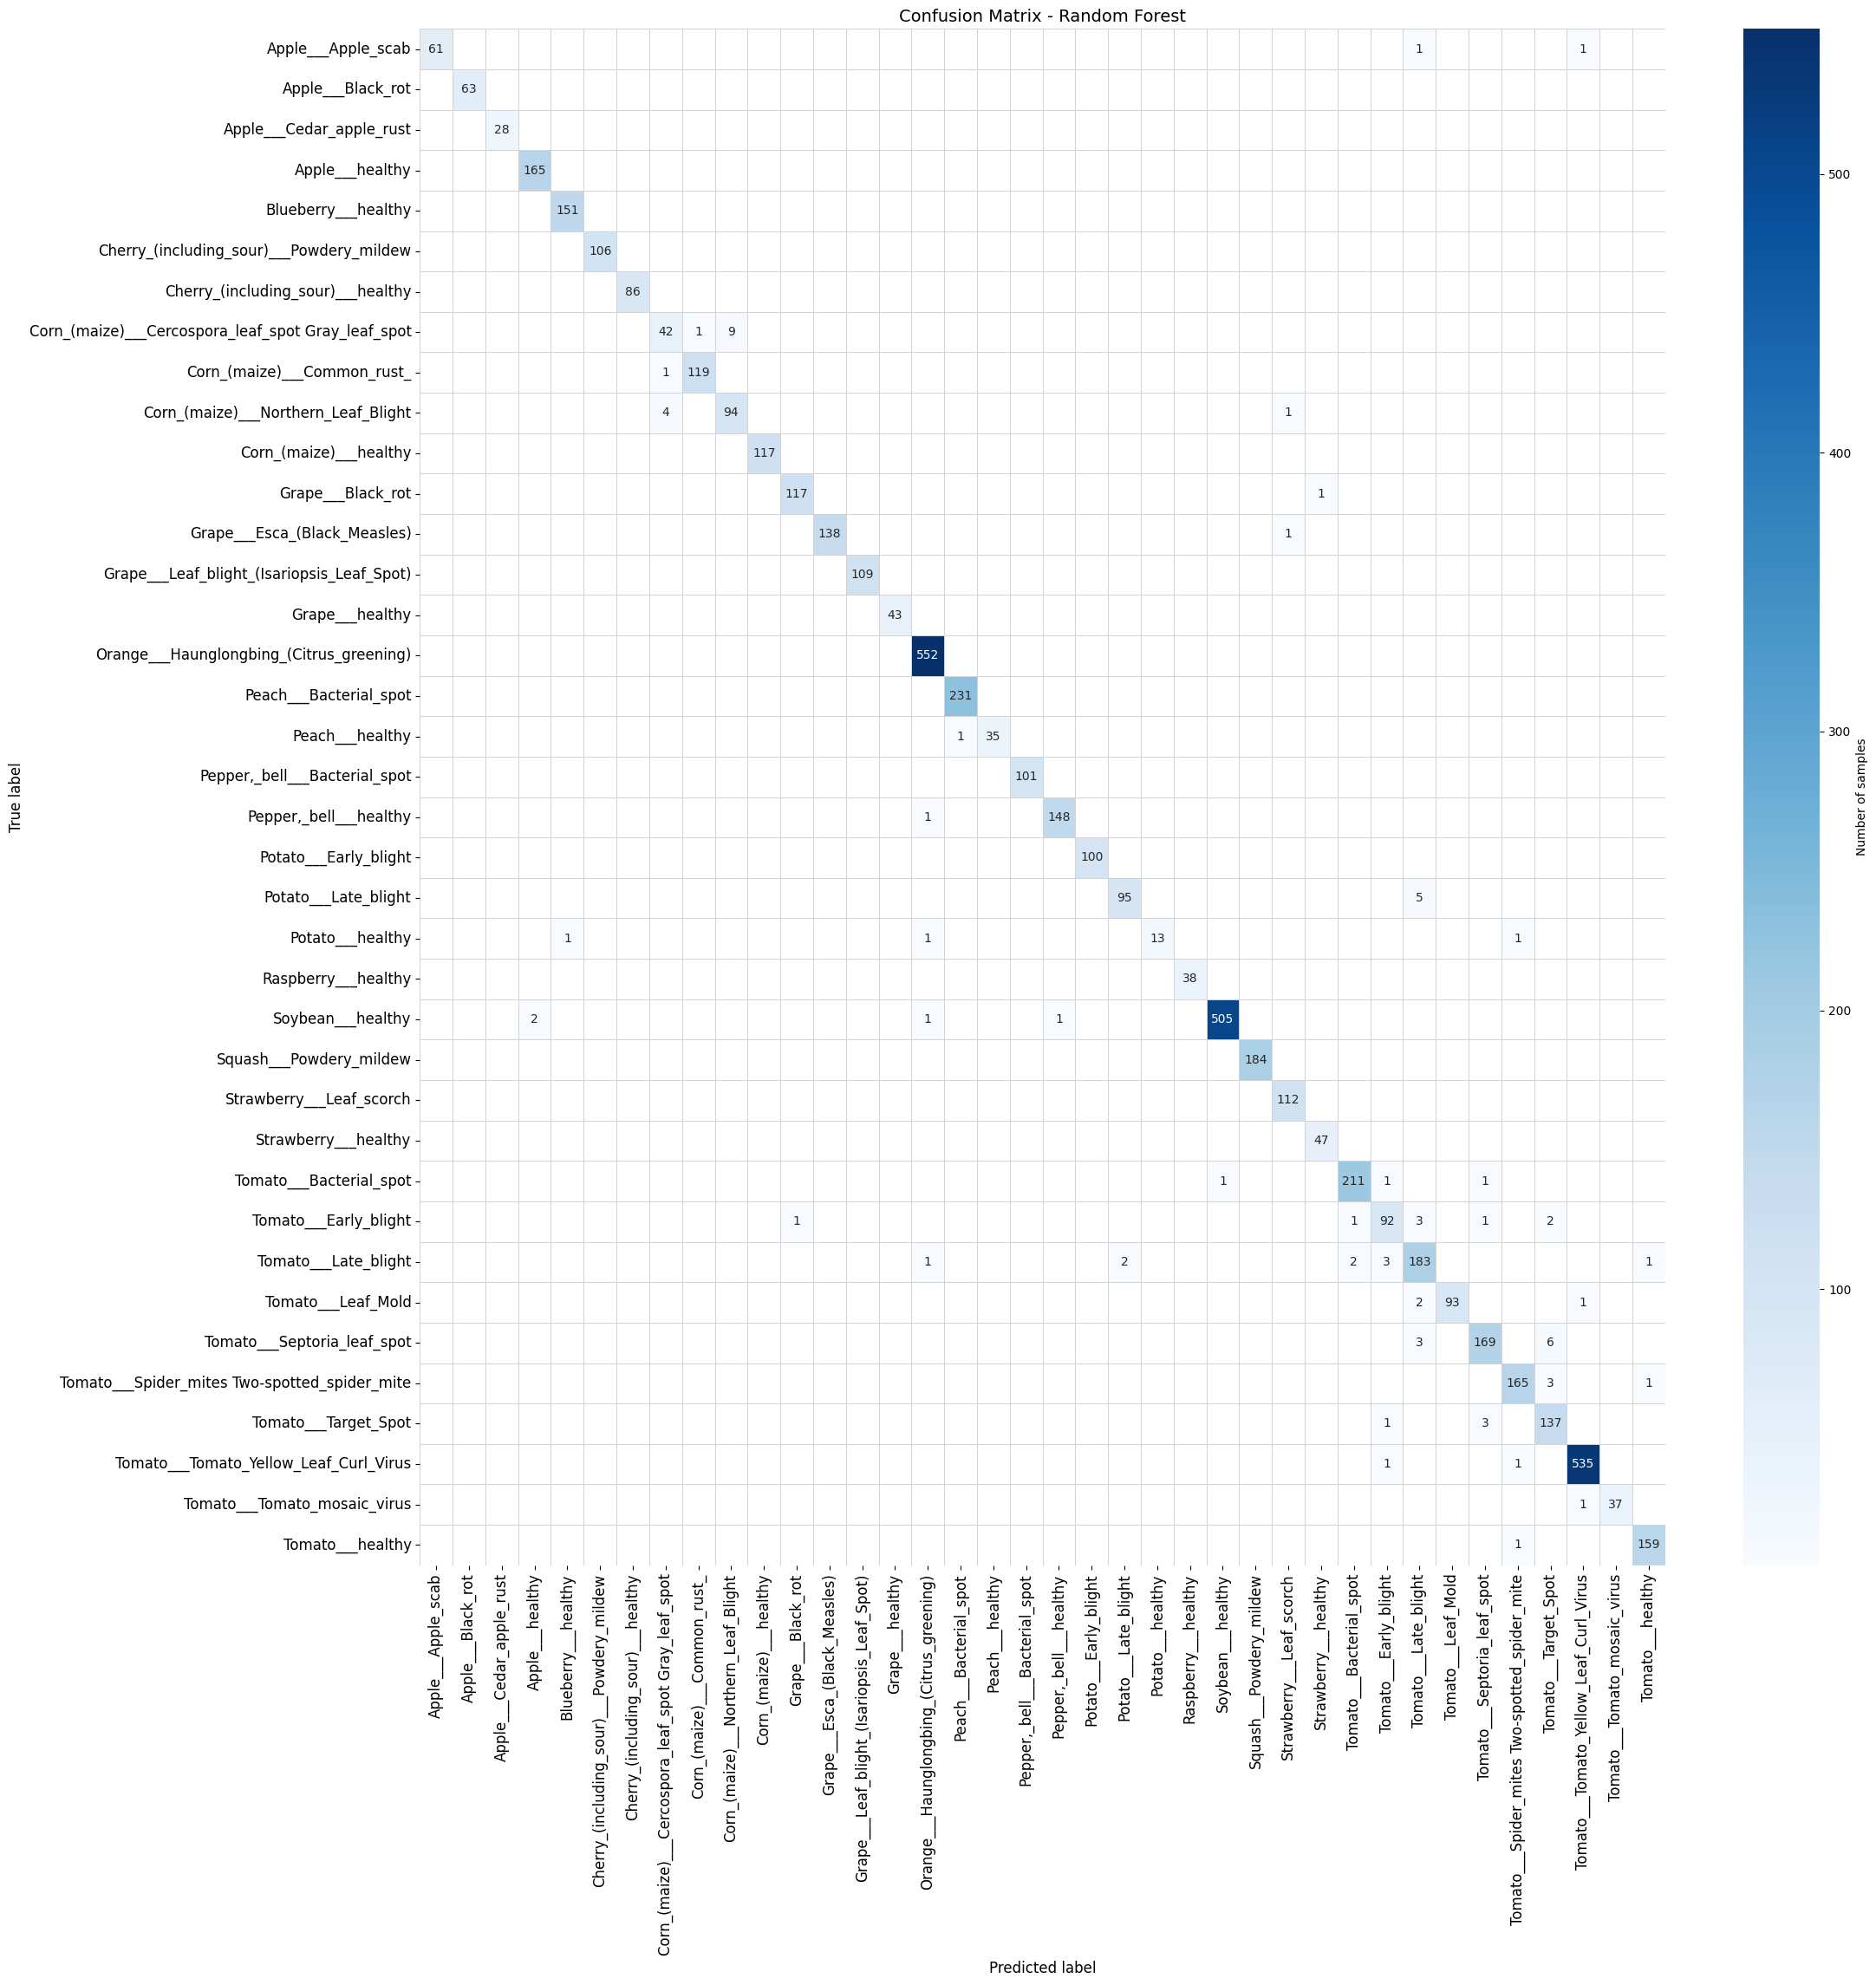

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

mask = cm == 0

annot = np.where(cm == 0, '', cm.astype(str))


n_classes = len(class_names)
fig, ax = plt.subplots(figsize=(n_classes * 0.5 + 4, n_classes * 0.5 + 4))

sns.heatmap(
    cm,
    mask=mask,          
    annot=annot,        
    fmt='',             
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgray',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of samples'},
    ax=ax
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix - Random Forest', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Salva l'immagine
plt.savefig('/kaggle/working/confusion_matrix_RF.png', dpi=300, bbox_inches='tight')
plt.show()

# SVM 

In [13]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

print("Classes:", len(label_encoder.classes_))

Classes: 38


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Before PCA:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nAfter PCA:")
print("X_train_pca:", X_train_pca.shape)
print("X_val_pca:  ", X_val_pca.shape)
print("X_test_pca: ", X_test_pca.shape)

Before PCA:
X_train: (43430, 512)
X_val:   (5417, 512)
X_test:  (5459, 512)

After PCA:
X_train_pca: (43430, 34)
X_val_pca:   (5417, 34)
X_test_pca:  (5459, 34)


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
regs = [0.1, 1, 10, 100]
kernels = ["rbf", "linear"]

results = {}

for kernel in kernels:
    for reg in regs:

        svm = SVC(
            C=reg,
            kernel=kernel,
            class_weight="balanced",
            random_state=42
        )

        svm.fit(X_train_pca, y_train)

        y_val_pred = svm.predict(X_val_pca)

        score = accuracy_score(y_val, y_val_pred)

        results[(kernel, reg)] = score

        print(
            f"Kernel = {kernel:6s} | "
            f"C = {reg} | "
            f"Validation Accuracy = {score:.4f}"
        )

best_params = max(results, key=results.get)
best_score = results[best_params]

best_kernel, best_reg = best_params
print("Best kernel: ", best_kernel, " best tolerance: ", best_reg)

Kernel = rbf    | C = 0.1 | Validation Accuracy = 0.9777
Kernel = rbf    | C = 1 | Validation Accuracy = 0.9839
Kernel = rbf    | C = 10 | Validation Accuracy = 0.9884
Kernel = rbf    | C = 100 | Validation Accuracy = 0.9893
Kernel = linear | C = 0.1 | Validation Accuracy = 0.9830
Kernel = linear | C = 1 | Validation Accuracy = 0.9821
Kernel = linear | C = 10 | Validation Accuracy = 0.9828
Kernel = linear | C = 100 | Validation Accuracy = 0.9821
Best kernel:  rbf  best tolerance:  100


In [21]:
best_kernel = "rbf"
best_reg = 100

In [22]:
import joblib
best_svm = SVC(
    C=best_reg,
    kernel=best_kernel,
    class_weight="balanced"
)

best_svm.fit(X_train_pca, y_train)

joblib.dump(best_svm, "/kaggle/working/modelSvm.pkl")
joblib.dump(pca, "/kaggle/working/pca.pkl")

['/kaggle/working/pca.pkl']

In [23]:
best_svm = joblib.load("/kaggle/working/modelSvm.pkl")
pca = joblib.load("/kaggle/working/pca.pkl")

X_test_pca = pca.transform(X_test)

In [24]:

y_pred = best_svm.predict(X_test_pca)

y_test_pred = best_svm.predict(X_test_pca)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)




Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9744    0.6032    0.7451        63
                                 Apple___Black_rot     0.7971    0.8730    0.8333        63
                          Apple___Cedar_apple_rust     1.0000    0.0357    0.0690        28
                                   Apple___healthy     1.0000    0.0061    0.0120       165
                               Blueberry___healthy     0.0000    0.0000    0.0000       151
          Cherry_(including_sour)___Powdery_mildew     0.9787    0.4340    0.6013       106
                 Cherry_(including_sour)___healthy     0.8889    0.6512    0.7517        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9524    0.3846    0.5479        52
                       Corn_(maize)___Common_rust_     0.9333    0.9333    0.9333       120
               Corn_(maize)___Northern_Leaf_Blight    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


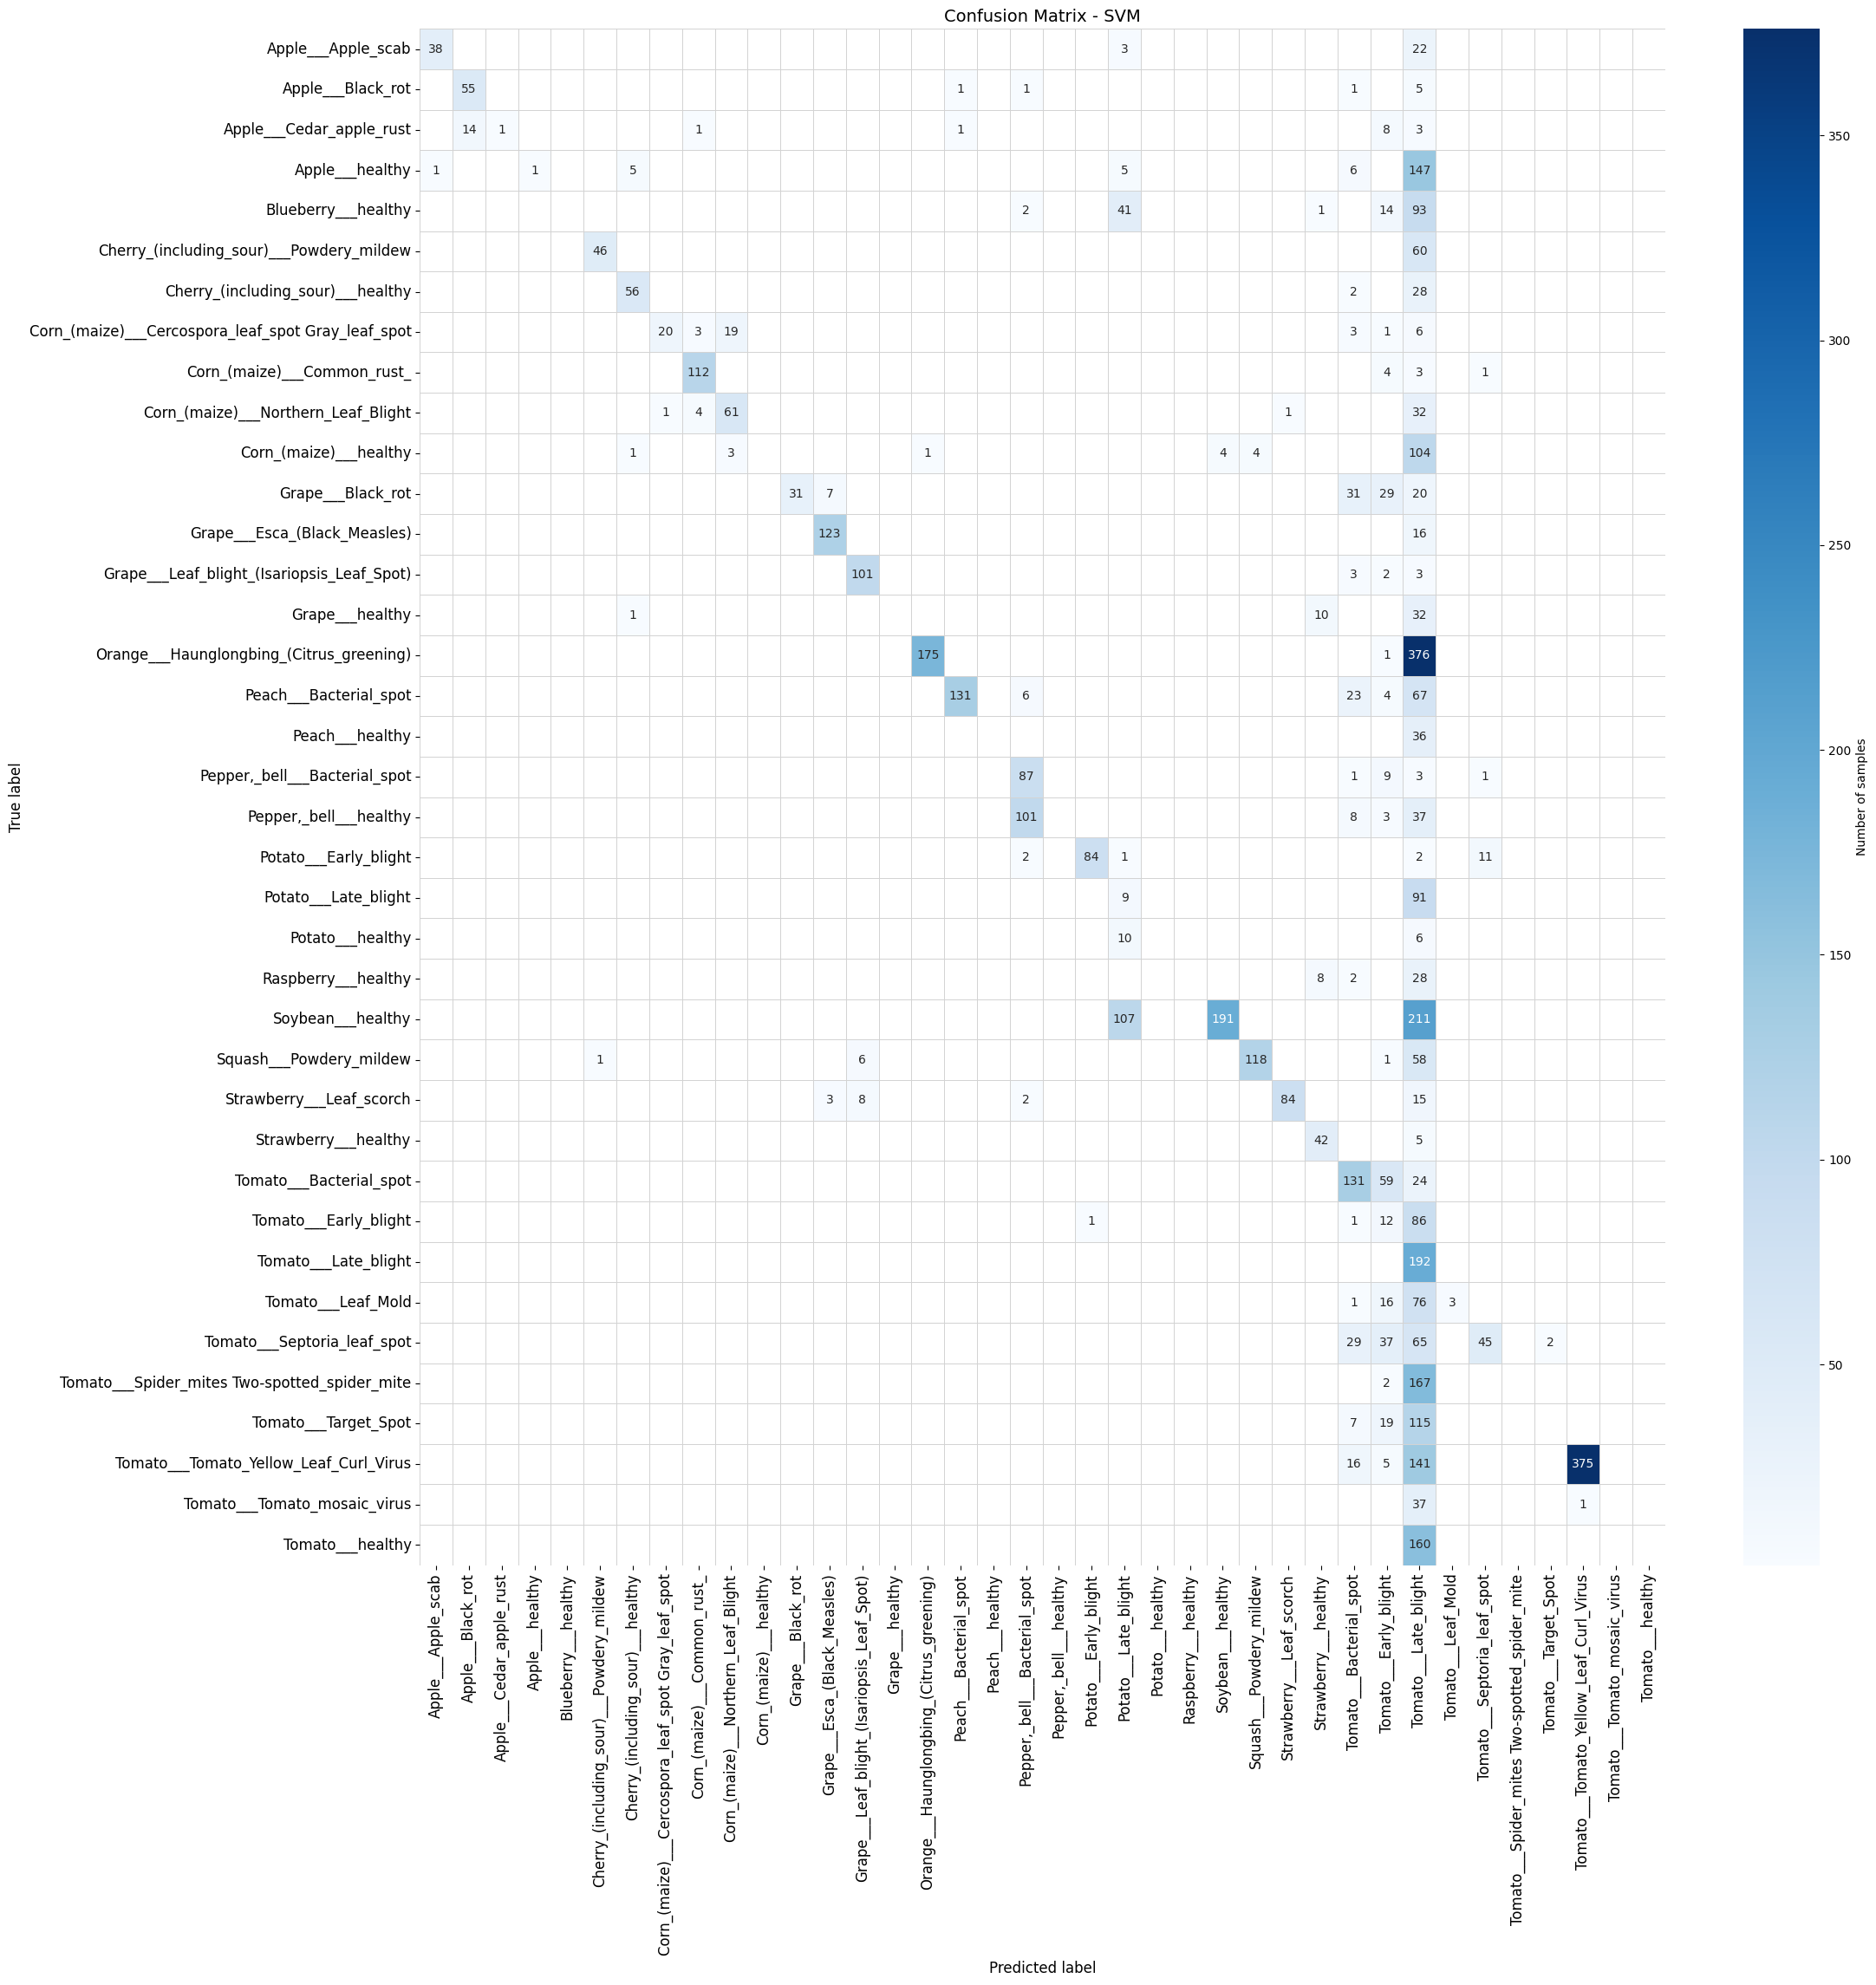

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

mask = cm == 0

annot = np.where(cm == 0, '', cm.astype(str))

n_classes = len(class_names)
fig, ax = plt.subplots(figsize=(n_classes * 0.5 + 4, n_classes * 0.5 + 4))

sns.heatmap(
    cm,
    mask=mask,          
    annot=annot,        
    fmt='',             
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgray',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of samples'},
    ax=ax
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix - SVM', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()


plt.savefig('/kaggle/working/confusion_matrix_SVM.png', dpi=300, bbox_inches='tight')
plt.show()

# Naive Bayes Classifier

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import numpy as np

from sklearn.preprocessing import StandardScaler

X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

X_train_nb = X_train.reshape(X_train.shape[0], -1)
X_val_nb   = X_val.reshape(X_val.shape[0], -1)
X_test_nb  = X_test.reshape(X_test.shape[0], -1)



Modello salvato


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "var_smoothing": np.logspace(-12, -1, 12)
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_nb, y_train)

for params, score in zip(
    grid_search.cv_results_["params"],
    grid_search.cv_results_["mean_test_score"]
):
    print(
        f"var_smoothing = {params['var_smoothing']:.12g} "
        f"--> accuracy CV = {score:.4f}"
    )

best_nb = grid_search.best_estimator_

print("\nMiglior parametro:")
print(grid_search.best_params_)

print("\nMiglior accuracy CV:")
print(grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
var_smoothing = 1e-12 --> accuracy CV = 0.9624
var_smoothing = 1e-11 --> accuracy CV = 0.9624
var_smoothing = 1e-10 --> accuracy CV = 0.9624
var_smoothing = 1e-09 --> accuracy CV = 0.9624
var_smoothing = 1e-08 --> accuracy CV = 0.9625
var_smoothing = 1e-07 --> accuracy CV = 0.9625
var_smoothing = 1e-06 --> accuracy CV = 0.9625
var_smoothing = 1e-05 --> accuracy CV = 0.9626
var_smoothing = 0.0001 --> accuracy CV = 0.9627
var_smoothing = 0.001 --> accuracy CV = 0.9632
var_smoothing = 0.01 --> accuracy CV = 0.9590
var_smoothing = 0.1 --> accuracy CV = 0.9300

Miglior parametro:
{'var_smoothing': np.float64(0.001)}

Miglior accuracy CV:
0.9631591066083353


In [29]:
model = GaussianNB(var_smoothing = 1e-3)

model.fit(X_train, y_train)
joblib.dump(model, "/kaggle/working/naive_bayes.joblib")
print("Modello salvato")

Modello salvato


In [30]:
model = joblib.load( "/kaggle/working/naive_bayes.joblib")
y_test_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {accuracy:.4f}")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

Test Accuracy: 0.9654
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9839    0.9683    0.9760        63
                                 Apple___Black_rot     1.0000    0.9841    0.9920        63
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        28
                                   Apple___healthy     0.9880    0.9939    0.9909       165
                               Blueberry___healthy     1.0000    0.9934    0.9967       151
          Cherry_(including_sour)___Powdery_mildew     0.9811    0.9811    0.9811       106
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8400    0.8077    0.8235        52
                       Corn_(maize)___Common_rust_     0.9914    0.9583    0.9746       120
               Corn_(maize)___Northern_Leaf_Blight     0.

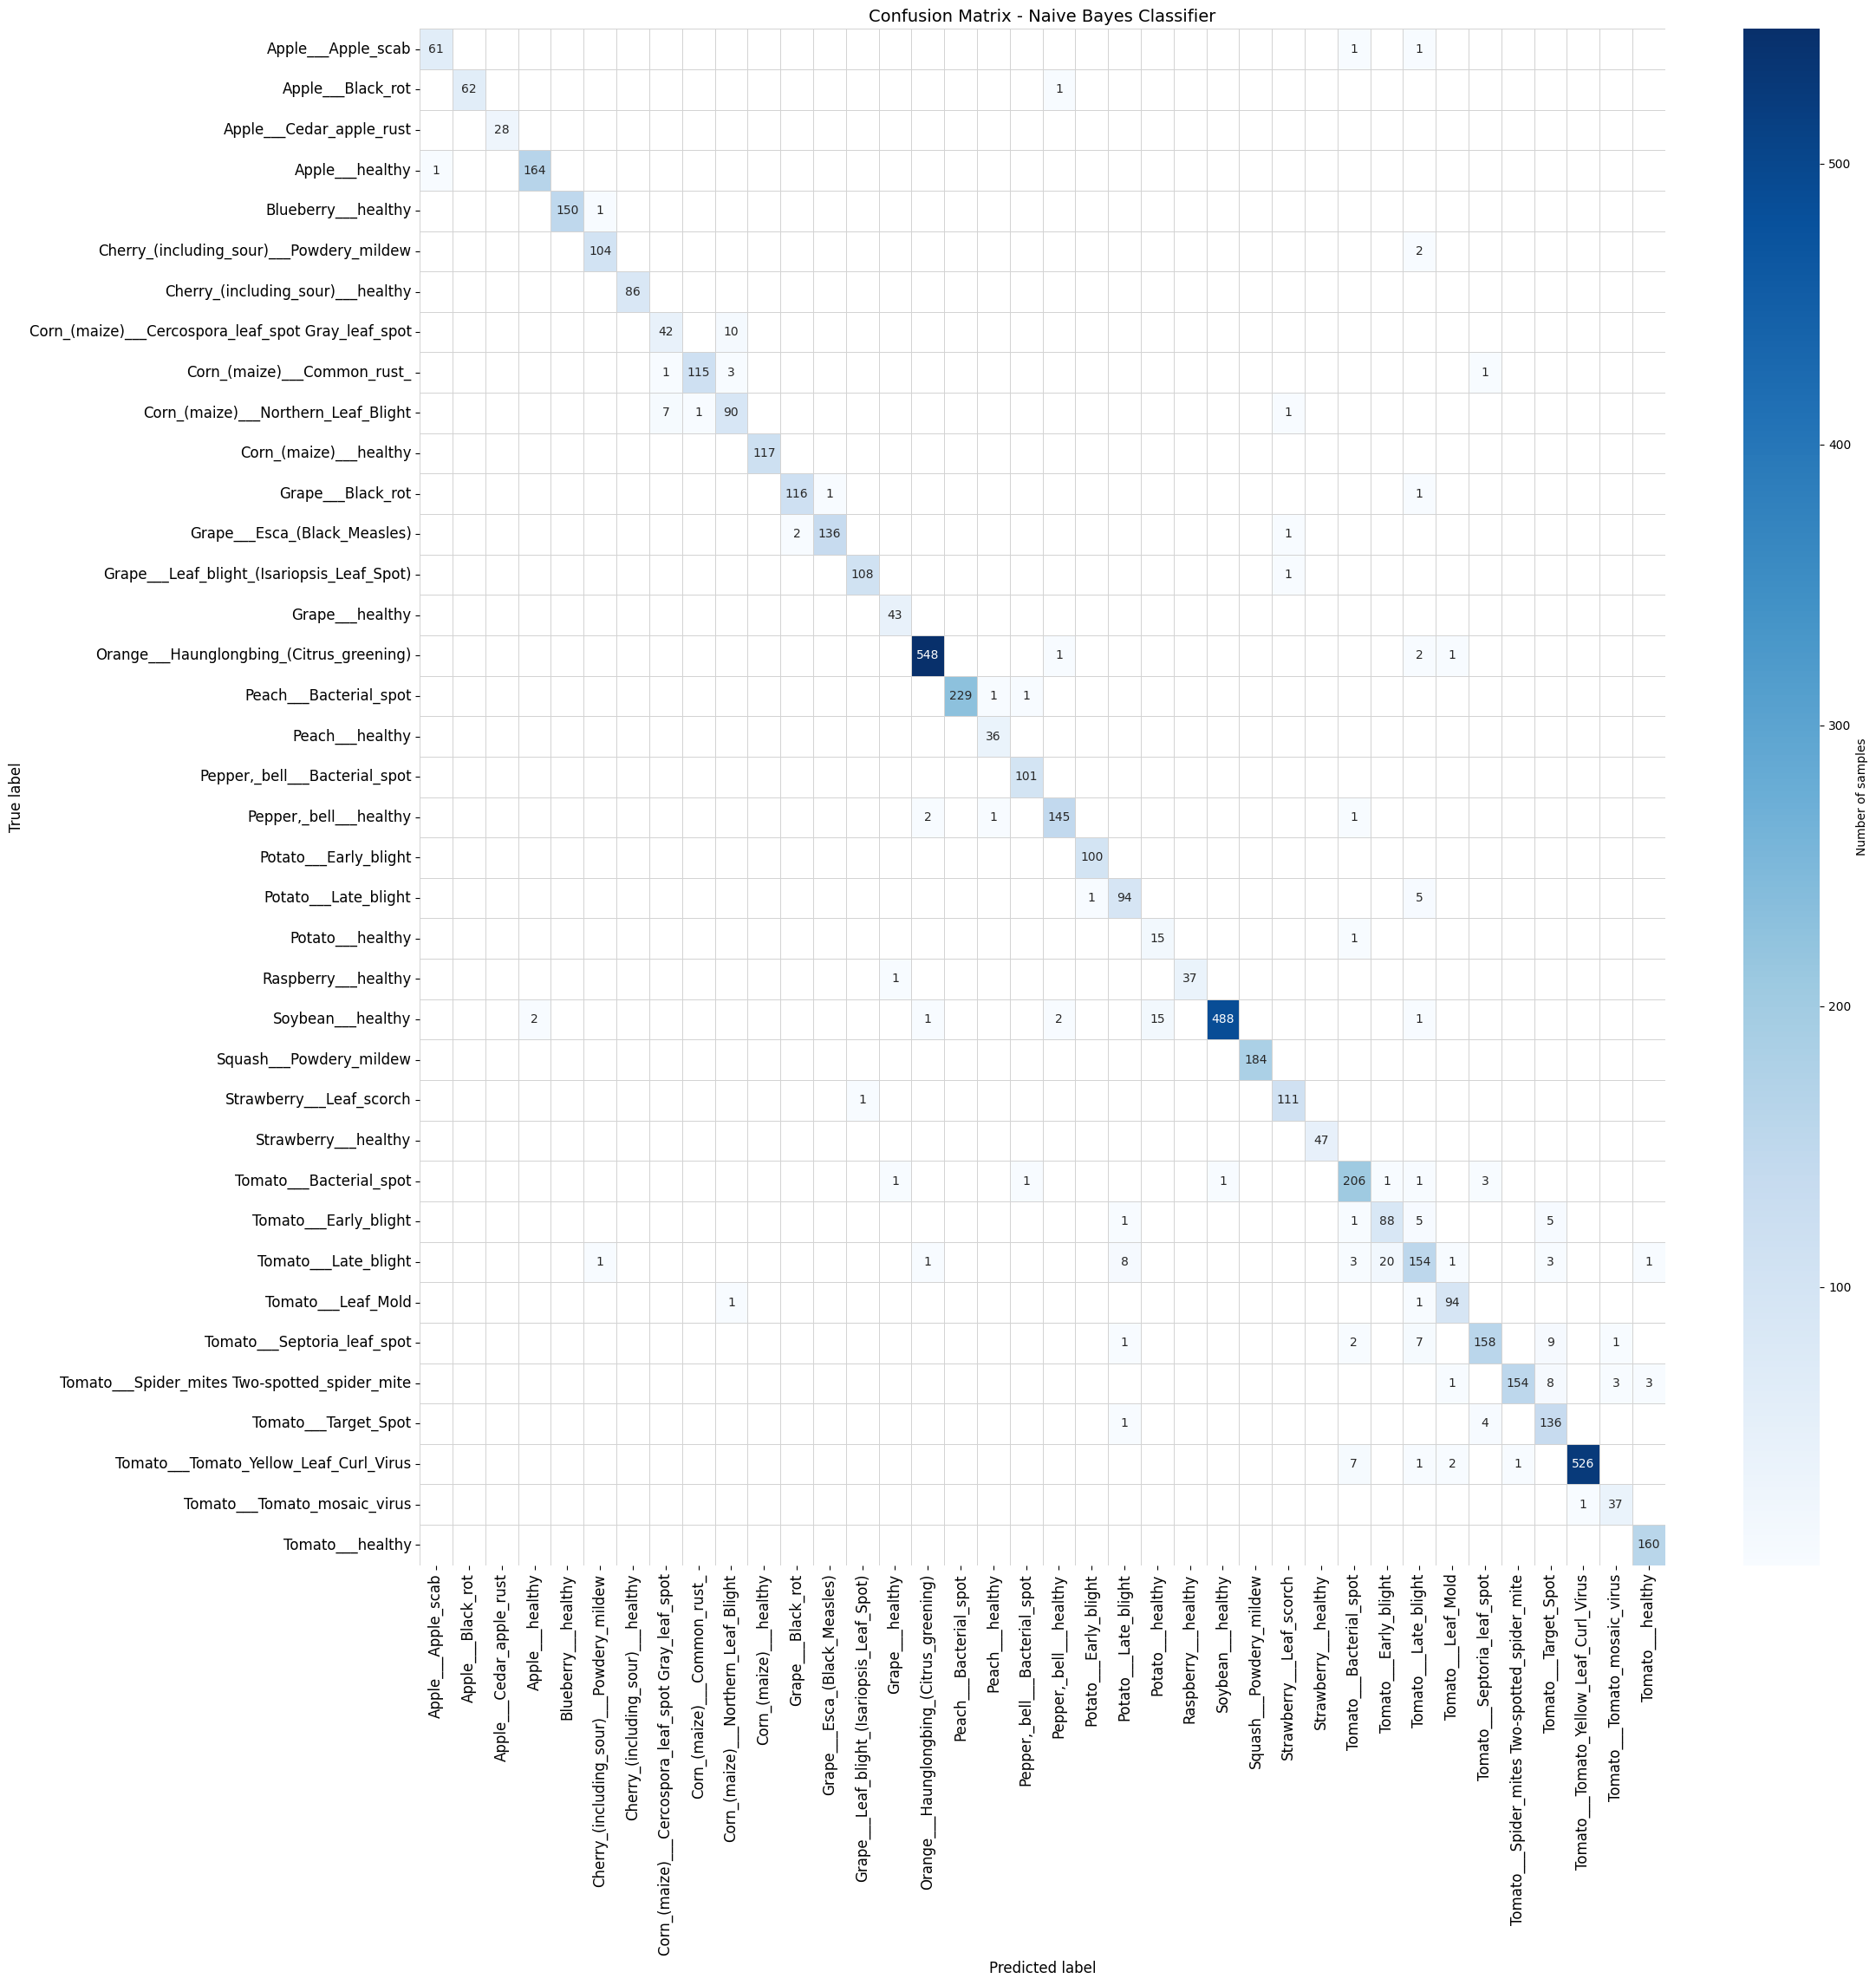

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

mask = cm == 0

annot = np.where(cm == 0, '', cm.astype(str))

# Dimensione figura proporzionale al numero di classi
n_classes = len(class_names)
fig, ax = plt.subplots(figsize=(n_classes * 0.5 + 4, n_classes * 0.5 + 4))

sns.heatmap(
    cm,
    mask=mask,          
    annot=annot,        
    fmt='',             
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgray',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of samples'},
    ax=ax
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix - Naive Bayes Classifier', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

plt.savefig('/kaggle/working/confusion_matrix_NBC.png', dpi=300, bbox_inches='tight')
plt.show()